In [1]:
# Step 1: Install required packages
!pip install -q openai numpy pandas matplotlib scikit-learn


In [2]:
# Step 2: Import libraries
from openai import OpenAI
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import os

In [3]:
# Step 3: Set your OpenAI API key
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
# Step 4: Initialize the OpenAI client
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


In [4]:
# Step 4: Create some sample sentences
texts = [
    "A cat is playing with a ball.",
    "A dog is running in the park.",
    "The sun is shining brightly today.",
    "Artificial intelligence is transforming education.",
    "Teachers are learning how to use AI tools.",
    "The weather is gloomy and it might rain.",
    "Students love learning about machine learning.",
]

In [5]:
# Step 5: Generate embeddings
response = client.embeddings.create(
    input=texts,
    model="text-embedding-3-small"   # you can use text-embedding-3-large for higher quality
)
embeddings = [item.embedding for item in response.data]

In [6]:
# Step 6: Convert to DataFrame
df = pd.DataFrame(embeddings)
df["text"] = texts
print("✅ Generated embeddings for", len(df), "sentences.")

✅ Generated embeddings for 7 sentences.


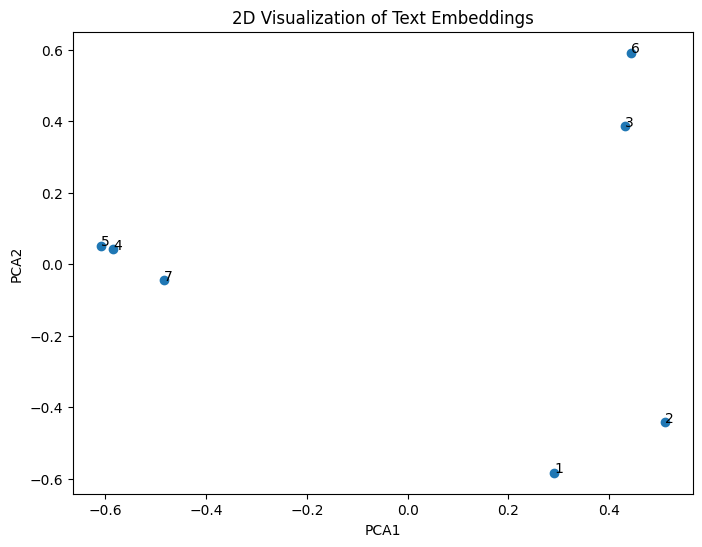

In [7]:
# Step 7: Visualize embeddings using PCA
pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1])
for i, txt in enumerate(texts):
    plt.annotate(f"{i+1}", (reduced[i,0], reduced[i,1]))
plt.title("2D Visualization of Text Embeddings")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

# Step 8: Find Similar Sentences
## Example Application: Semantic Search

In [8]:
# Choose a query
query = "AI in education"

# Get embedding for query
query_emb = client.embeddings.create(
    input=[query],
    model="text-embedding-3-small"
).data[0].embedding

# Compute cosine similarity
similarities = cosine_similarity([query_emb], embeddings)[0]
results = pd.DataFrame({"Text": texts, "Similarity": similarities})
print("\n🔍 Top similar sentences:")
print(results.sort_values(by="Similarity", ascending=False))



🔍 Top similar sentences:
                                                Text  Similarity
3  Artificial intelligence is transforming educat...    0.684719
4         Teachers are learning how to use AI tools.    0.658321
6     Students love learning about machine learning.    0.460577
0                      A cat is playing with a ball.    0.114828
2                 The sun is shining brightly today.    0.051029
5           The weather is gloomy and it might rain.    0.015593
1                      A dog is running in the park.    0.000606


# Step 9: Try Your Own Sentences

# Optional Extension

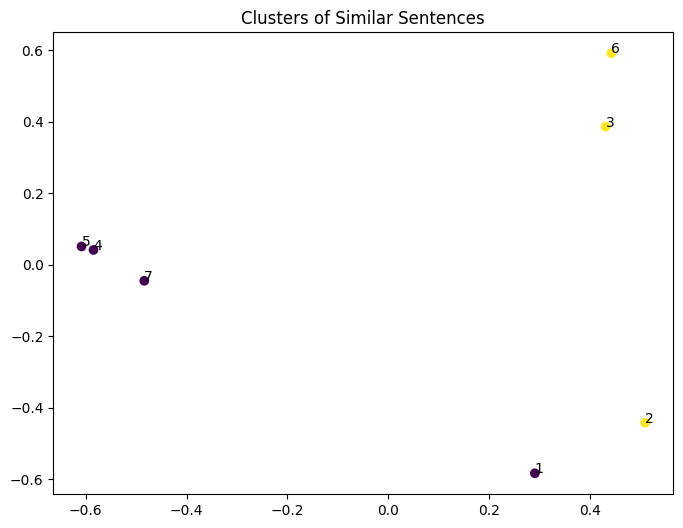

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0)
labels = kmeans.fit_predict(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:,0], reduced[:,1], c=labels, cmap='viridis')
for i, txt in enumerate(texts):
    plt.annotate(f"{i+1}", (reduced[i,0], reduced[i,1]))
plt.title("Clusters of Similar Sentences")
plt.show()
